In [95]:
import os
import jax

from jax import numpy as np, random as jr

jax.config.update("jax_enable_x64", True)

import amigo
import dorito
import astropy

# from optim_funcs import sgd, adam

# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots
import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 250
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

In [2]:
from socket import gethostname

if gethostname() == "glinton":
    path = "/media/morgana1/snert/max/"
elif gethostname() == "maxs-mbp-14.research.sydney.edu.au":
    path = "/Volumes/morgana1/snert/max/"
else:
    path = "/fred/oz440/max/"

save_path = "/Users/mc/data/dorito_figs/"


def load_fits(source_name):
    if source_name == "NGC1068":
        data_path = os.path.join(path, f"data/JWST/{source_name}/new_calslope/")
    else:
        data_path = os.path.join(path, f"data/JWST/{source_name}/calslope/")
    uncal_path = os.path.join(path, f"data/JWST/{source_name}/uncal/")
    amigo_cache = os.path.join(path, "data/amigo_files/")

    cache = os.path.join(amigo_cache, "v_0.0.10/")
    output_path = os.path.join(amigo_cache, f"outputs/{source_name}/")

    EXP_TYPE = "NIS_AMI"
    FILTERS = [
        "F480M",
        "F430M",
        "F380M",
        # "F277W",
    ]

    # Bind file path, type and exposure type
    file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
        data_path,
        "calslope",
        EXP_TYPE=EXP_TYPE,
        FILTER=filters,
        **kwargs,
    )

    files = sorted(
        file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
    )
    sci_files = []
    cal_files = []

    for file in files:

        # manual bad pixel correction
        file["BADPIX"].data[58, 67] = 1
        file["BADPIX"].data[71, 22] = 1
        file["BADPIX"].data[65, 41] = 1
        file["BADPIX"].data[35, 70] = 1
        file["BADPIX"].data[70, 55] = 1
        file["BADPIX"].data[5, 5] = 1
        file["BADPIX"].data[-4, 37] = 1
        file["BADPIX"].data[51, 27] = 1
        file["BADPIX"].data[28, 18] = 1
        file["BADPIX"].data[32, 10] = 1

        file["BADPIX"].data[:, :3] = 1
        file["BADPIX"].data[:, -3:] = 1
        file["BADPIX"].data[:3, :] = 1
        file["BADPIX"].data[-3:, :] = 1

        if file[0].header["TARGPROP"] == "TD-PDS-70":
            file["BADPIX"].data[:66, :25] = 1  # BACKGROUND STAR?
            file["BADPIX"].data[36:66, :25] = 1  # BACKGROUND STAR?
            file["BADPIX"].data[17, 70] = 1
            file["BADPIX"].data[19, 53] = 1
            file["BADPIX"].data[5, 22] = 1
            file["BADPIX"].data[19, 41] = 1
            file["BADPIX"].data[76, 45] = 1
            file["BADPIX"].data[59, 30] = 1

        if not bool(file[0].header["IS_PSF"]):
            sci_files.append(file)
        elif bool(file[0].header["IS_PSF"]):
            cal_files.append(file)
        else:
            print(f"Unkown target: {file[0].header['TARGPROP']}")
    return sci_files, cal_files


io_sci_files, io_cal_files = load_fits("IO")
ngc_sci_files, ngc_cal_files = load_fits("NGC1068")
wr137_sci_files, wr137_cal_files = load_fits("WR137")

In [18]:
ngc_cal_fits = [
    amigo.model_fits.PointFit(file)
    for file in ngc_cal_files
    if file[0].header["FILTER"] == "F480M"
]
ngc_sci_fits = [
    amigo.model_fits.PointFit(file)
    for file in ngc_sci_files
    # if file[0].header["FILTER"] == "F480M"
]

io_sci_fits = [
    amigo.model_fits.PointFit(file)
    for file in io_sci_files
    if file[0].header["FILTER"] == "F430M"
]

io_cal_fits = [
    amigo.model_fits.PointFit(file)
    for file in io_cal_files
    if file[0].header["FILTER"] == "F430M"
]

wr137_sci_fits = [
    amigo.model_fits.PointFit(file)
    for file in wr137_sci_files
    if file[0].header["FILTER"] == "F380M"
]
wr137_cal_fits = [
    amigo.model_fits.PointFit(file)
    for file in wr137_cal_files
    if file[0].header["FILTER"] == "F380M"
]

# Interferograms

In [19]:
interferograms = {}

# ngc
badpix = ngc_sci_fits[-1].badpix
ngc_data = ngc_sci_fits[-1].slopes[-1]
ngc_data = np.where(badpix, np.nan, ngc_data)
interferograms["NGC1068"] = ngc_data

# io
badpix = io_sci_fits[0].badpix
io_data = io_sci_fits[0].slopes[18]
io_data = np.where(badpix, np.nan, io_data)
interferograms["IO"] = io_data


# wr137
badpix = wr137_sci_fits[0].badpix
wr137_data = wr137_sci_fits[0].slopes[-1]
wr137_data = np.where(badpix, np.nan, wr137_data)
interferograms["WR137"] = wr137_data


# ngc cal
badpix = ngc_cal_fits[0].badpix
ngc_cal_data = ngc_cal_fits[0].slopes[-1]
ngc_cal_data = np.where(badpix, np.nan, ngc_cal_data)
interferograms["HD17130"] = ngc_cal_data


# io cal
badpix = io_cal_fits[0].badpix
io_cal_data = io_cal_fits[0].slopes[-1]
io_cal_data = np.where(badpix, np.nan, io_cal_data)
interferograms["HD2236"] = io_cal_data


# wr137 cal
badpix = wr137_cal_fits[0].badpix
wr137_cal_data = wr137_cal_fits[0].slopes[-1]
wr137_cal_data = np.where(badpix, np.nan, wr137_cal_data)
interferograms["HD228337"] = wr137_cal_data

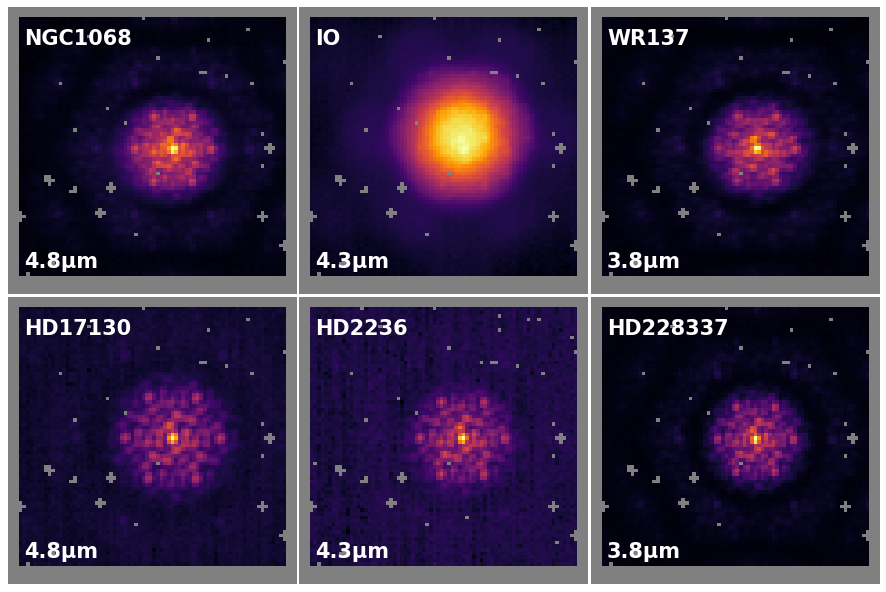

In [20]:
plt.figure(figsize=(15 / 2, 5))

for i, key in enumerate(interferograms.keys()):
    plt.subplot(2, 3, i + 1)
    plt.axis("off")
    plt.imshow(
        interferograms[key],
        cmap=inferno,
        norm=mpl.colors.PowerNorm(0.5),
        aspect="auto",
    )
    font_dict = {"family": "sans-serif", "color": "white", "size": 10, "weight": "bold"}

    match i % 3:
        case 0:
            filt = "4.8μm"
        case 1:
            filt = "4.3μm"
        case 2:
            filt = "3.8μm"
    plt.text(4, 69, key, fontdict=font_dict)
    plt.text(4, 7, filt, fontdict=font_dict)

    # plt.subplot(2, 3, 1)

plt.subplots_adjust(hspace=0.01, wspace=0.01)
plt.savefig(f"{save_path}/interferograms.pdf", dpi=500, bbox_inches="tight")
plt.show()

# Images

In [31]:
def get_dist(params_path, filt):
    params = np.load(params_path, allow_pickle=True).item()
    dist = 10 ** params["log_dist"][filt]
    return dist


best_images = {}

## NGC1068

In [115]:
ngc_disco = get_dist(f"{save_path}/ngc1068/implane.npy", "F480M")


def get_rgb_dist(fits, params_path, filt):
    params = np.load(params_path, allow_pickle=True).item()
    dist = 10 ** params["log_dist"][f"2025_{filt}"]

    fluxes = []
    for exp in fits:
        if exp.calibrator:
            raise ValueError("Expected science exposure, got calibrator")
        if exp.filter != filt:
            continue
        try:
            flux = params["fluxes"][exp.get_key("fluxes")]
            fluxes.append(flux)
        except:
            pass
    flux = 10 ** (np.array(fluxes).mean())

    return flux, dist


ngc_implane_dict = {
    filt: get_rgb_dist(ngc_sci_fits, f"{save_path}/ngc1068/implane/{filt}.npy", filt)
    for filt in ["F480M", "F430M", "F380M"]
}

# ngc_implane_dict["F480M"] =
# ngc_implane_dict["F430M"] = get_rgb_dist(
#     ngc_sci_fits, f"{save_path}/ngc1068/implane/F430M.npy", "F430M"
# )
# ngc_implane_dict["F380M"] = get_rgb_dist(
#     ngc_sci_fits, f"{save_path}/ngc1068/implane/F380M.npy", "F380M"
# )

[Array(1206266.55520426, dtype=float64), Array(818315.87913315, dtype=float64), Array(817157.74509691, dtype=float64)] 1206266.555204256


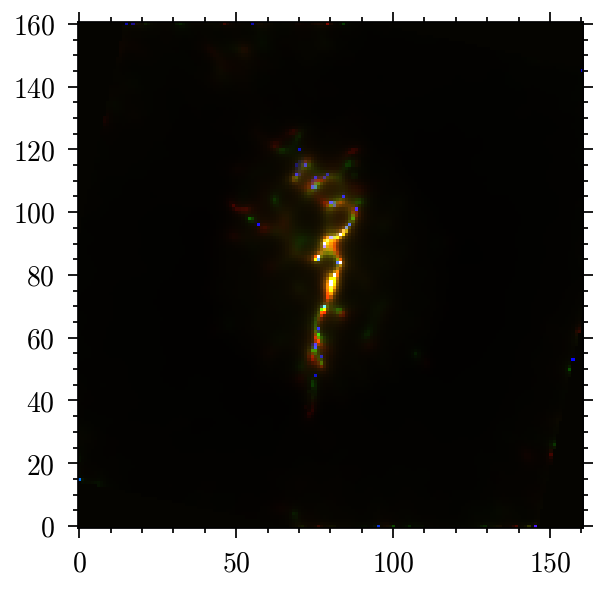

In [116]:
gamma = 2
clip = 0.1

fluxes = [ngc_implane_dict[filt][0] for filt in ngc_implane_dict]
max_flux = max(fluxes)
print(fluxes, max_flux)

r = ngc_implane_dict["F480M"][0] * ngc_implane_dict["F480M"][1] / max_flux
g = ngc_implane_dict["F430M"][0] * ngc_implane_dict["F430M"][1] / max_flux
b = ngc_implane_dict["F380M"][0] * ngc_implane_dict["F380M"][1] / max_flux

pix_max = max([r.max(), g.max(), b.max()])
r /= pix_max
g /= pix_max
b /= pix_max

r = r ** (1 / gamma)
g = g ** (1 / gamma)
b = b ** (1 / gamma)

r = np.clip(r, 0, clip) / clip
g = np.clip(g, 0, clip) / clip
b = np.clip(b, 0, clip) / clip

ngc_implane = np.stack((r, g, b), axis=2)
plt.imshow(ngc_implane)

best_images["NGC1068"] = {
    "implane": ngc_implane,
    "disco": ngc_disco / ngc_disco.max(),
}

## Io

In [117]:
io_implane = get_dist(f"{save_path}/ngc1068/implane.npy", "F480M")
io_disco = get_dist(f"{save_path}/ngc1068/implane.npy", "F480M")
best_images["IO"] = {
    "implane": io_implane / io_implane.max(),
    "disco": io_disco / io_disco.max(),
}

## WR137

In [118]:
wr137_implane = get_dist(f"{save_path}/ngc1068/implane.npy", "F480M")
wr137_disco = get_dist(f"{save_path}/ngc1068/implane.npy", "F480M")
best_images["WR137"] = {
    "implane": wr137_implane / wr137_implane.max(),
    "disco": wr137_disco / wr137_disco.max(),
}

In [119]:
from dorito.plotting import get_arcsec_extents


def plot_result(
    ax,
    array,
    pixel_scale,
    roll_angle_degrees: float = None,
    cmap: str = "afmhot_10u",
    bg_color: str = "k",
    axis_labels: dict = {
        "xlabel": r"$\Delta$RA [arcsec]",
        "ylabel": r"$\Delta$DEC [arcsec]",
    },
    norm=mpl.colors.PowerNorm(1, vmin=0, vmax=None),
    diff_lim: float = None,
    scale=1.0,
    translate=(0.0, 0.0),
    ticks=[0.5, 0, -0.5],
    **kwargs,
):

    ax.set_facecolor(bg_color)  # Set the background colour
    ax.tick_params(direction="out")
    ax.set(
        xticks=ticks,
        yticks=ticks[::-1],
        **axis_labels,
    )  # Set the axis labels

    kwargs = {
        "cmap": cmap,
        "extent": get_arcsec_extents(pixel_scale / scale, array.shape),
        "norm": norm,
        "aspect": "equal",
    }

    im = ax.imshow(
        array,
        **kwargs,
    )

    if diff_lim is not None:

        centre = 0.95 * np.array(kwargs["extent"][0:2]) + np.array(
            [-diff_lim, diff_lim]
        )

        beam = mpl.patches.Circle(
            centre,
            radius=diff_lim,
            facecolor="white",
            edgecolor="black",
            alpha=0.7,
            zorder=10,
        )
        ax.add_patch(beam)

    if roll_angle_degrees is not None or scale is not None:

        if scale is None:
            scale = 1.0
        if roll_angle_degrees is None:
            roll_angle_degrees = 0.0

        rotation_transform = (
            mpl.transforms.Affine2D()
            .translate(*translate)
            .rotate_deg(roll_angle_degrees)
            .scale(scale)
        )  # Create a rotation transformation
        trans_data = rotation_transform + ax.transData  # creating transformation
        im.set_transform(trans_data)  # applying transformation to image

    return im

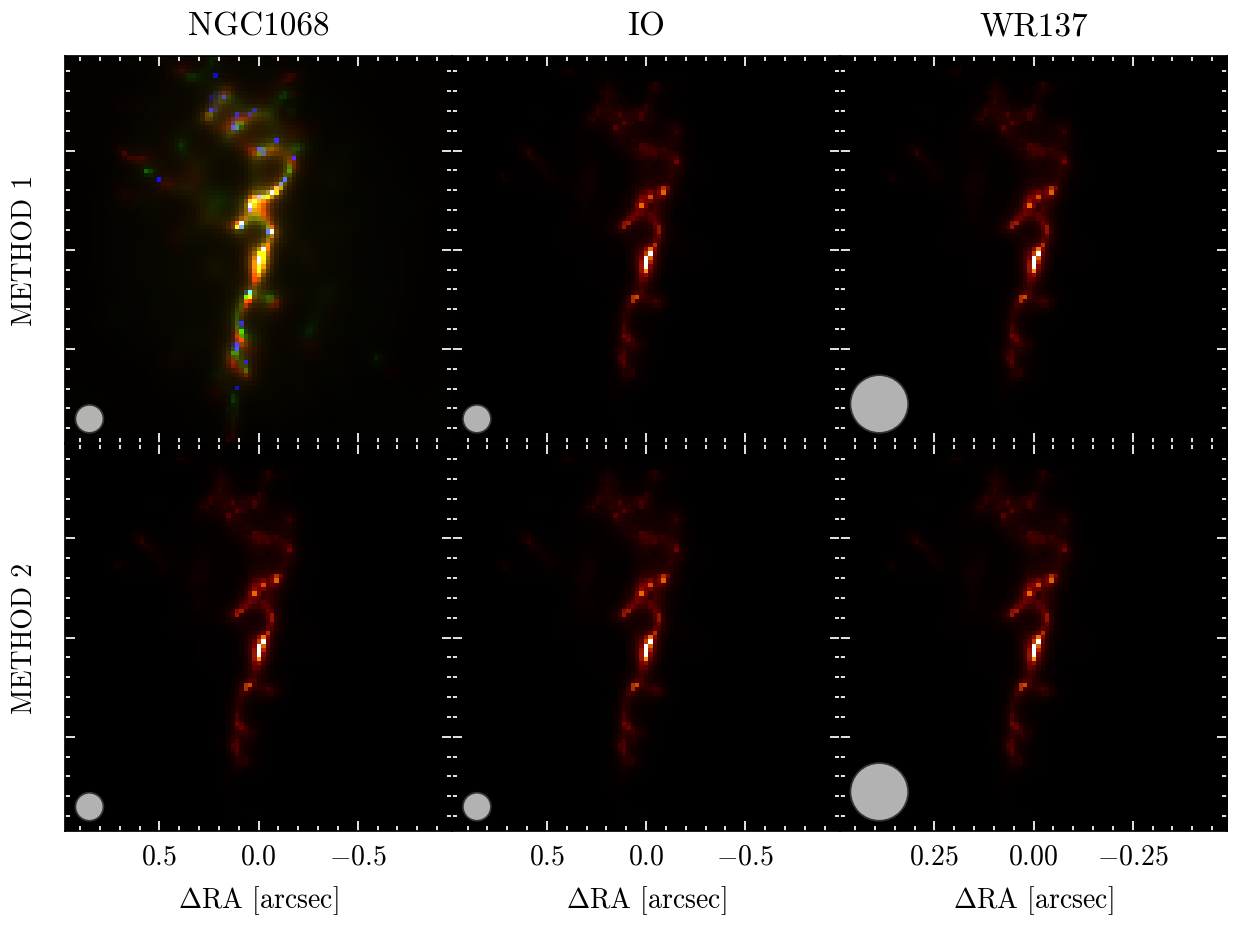

In [133]:
from dLux import utils as dlu

psf_pixel_scale = 0.065524085  # arcsec / pixel
diameter = 6.603464  # meters

fig, axes = plt.subplots(2, 3, figsize=(6, 4.03))  # , sharex=True, sharey=True)

for i, key in enumerate(list(best_images.keys())):

    for image, row in zip(
        [best_images[key]["implane"], best_images[key]["disco"]], [0, 1]
    ):
        osamp = 3 if i != 2 else 6
        ticks = [-0.5, 0, 0.5] if i != 2 else [-0.25, 0, 0.25]

        im = plot_result(
            axes[row, i],
            image,
            psf_pixel_scale / osamp,
            cmap="afmhot_u",
            scale=1.8,
            norm=mpl.colors.PowerNorm(0.5, vmin=0, vmax=0.15),
            # norm=mpl.colors.LogNorm(vmin=2e-4),
            diff_lim=dlu.rad2arcsec(4.8e-6 / (2 * diameter)),
            aspect="auto",
            axis_labels={"xlabel": "", "ylabel": ""},
            ticks=ticks,
        )
    if i == 0:
        axes[0, i].set(ylabel="METHOD 1")
        axes[1, i].set(ylabel="METHOD 2")

    # if i != 0:
    #     for j in [0, 1]:
    #         axes[j, i].tick_params(which="both", left=False)

    # if i != 2:
    #     for j in [0, 1]:
    #         axes[j, i].tick_params(which="both", right=False)

    # axes[0, i].tick_params(which="both", bottom=False)
    # axes[1, i].tick_params(which="both", top=False)
    axes[0, i].tick_params(which="both", color="white", direction="in")
    axes[1, i].tick_params(which="both", color="white", direction="in")

    axes[0, i].set(title=key, yticklabels=["", "", ""])
    axes[1, i].set(xlabel=r"$\Delta$RA [arcsec]", yticklabels=["", "", ""])
    # font_dict = {"family": "sans-serif", "color": "white", "size": 10, "weight": "bold"}


fig.subplots_adjust(hspace=0.0, wspace=0.0)
# plt.savefig(f"{save_path}/.pdf", dpi=500, bbox_inches="tight")
plt.show()